In [3]:
!pip install pennylane
import pennylane as qml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 98.7 MB/s eta 0:00:00


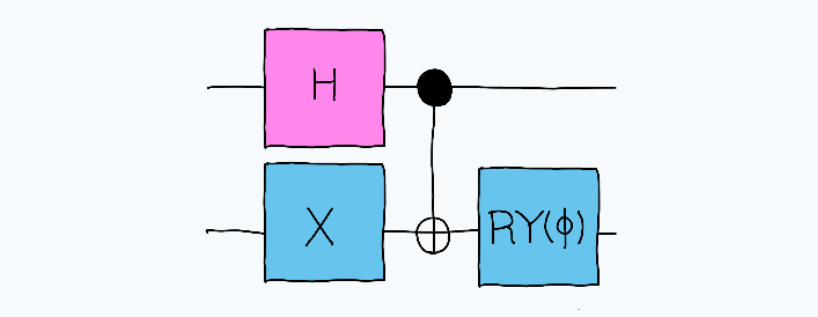

In [1]:
def circuit(phi): # Write any arguments you need here
    """
    This quantum function implements the circuit shown above
    and returns the output quantum state
    """

    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.CNOT(wires=[0,1])
    qml.RY(phi, wires=1)

    return qml.state()

In [4]:
dev_qubit = qml.device("default.qubit", wires=["alice","bob"]) # Define the device here
dev_mixed = qml.device("default.mixed", wires = 2) # Define the device here

@qml.qnode(dev_qubit) # Choose the device you want
def example_circuit(theta):

    qml.RX(theta, wires = "alice" ) # Complete with wires in the device
    qml.CNOT(wires = ["alice","bob"] ) # Complete with wires in the device

    return qml.state()

print(example_circuit(0.3))

[0.98877108+0.j         0.        +0.j         0.        +0.j
 0.        -0.14943813j]


In [5]:
dev = qml.device("default.qubit", wires=2)

def circuit(phi):
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.CNOT(wires=[0,1])
    qml.RY(phi, wires=1)

    return qml.state()

circuit_qnode = qml.QNode(circuit, dev)

print(circuit_qnode(0.3))

[-0.10566872+0.j  0.69916673+0.j  0.69916673+0.j  0.10566872+0.j]


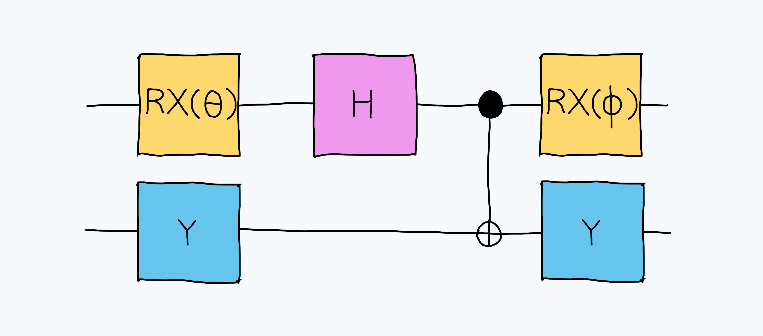

In [6]:
def subcircuit_1(angle):

    qml.RX(angle, wires = 0)
    qml.PauliY(wires = 1)

    # No need to return anything

def subcircuit_2():

    qml.Hadamard(wires = 0)
    qml.CNOT(wires = [0,1])

    # No need to return anything

dev = qml.device('default.qubit', wires = 2)

@qml.qnode(dev)# Decorate this function to create a QNode
def full_circuit(theta, phi):

    subcircuit_1(theta)
    subcircuit_2()
    subcircuit_1(phi)

    return qml.state()

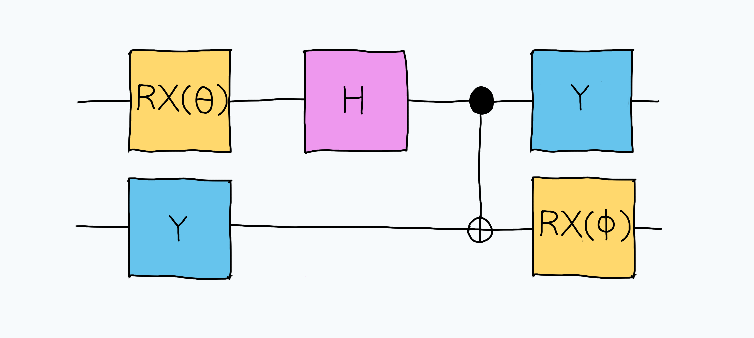

In [7]:
def subcircuit_1(angle, wire_list):
    """
    Implements the first subcircuit as a function of the RX gate angle
    and the list of wires wire_list on which the gates are applied
    """
    qml.RX(angle, wires = wire_list[0])
    qml.PauliY(wires = wire_list[1])

def subcircuit_2(wire_list):
    """
    Implements the second subcircuit as a function of the list of wires
    wire_list on which the gates are applied
    """

    qml.Hadamard(wires = wire_list[0])
    qml.CNOT(wires=[wire_list[0], wire_list[1]])

dev = qml.device("default.qubit", wires = [0,1])

@qml.qnode(dev)
def full_circuit(theta, phi):
    """
    Builds the full quantum circuit given the input parameters
    """

    subcircuit_1(theta, wire_list=[0,1])
    subcircuit_2(wire_list=[0,1])
    subcircuit_1(phi, wire_list=[1,0])

    return qml.state()